In [1]:
import sys

sys.path.append("..")
sys.path.append("../..")

In [2]:
import os
import copy
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join as pjoin

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn
from torch import optim

from peft import LoraConfig, get_peft_model

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from utils.misc import load_config, load_model_from_checkpoint, print_trainable_parameters, load_policy_encoder_from_pretraining
from datasets.data_preparation import prepare_data

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_path = '../../results/dl.vit/2023-09-11 11Hr 50Min 06Sec IST+0530'
encoder_checkpoint_path = None#'../pretraining/encoder/dl.vit/2023-08-21 18Hr 09Min 32Sec IST+0530/checkpoint.pt'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [4]:
trainer_config = config['trainer']
data_config = config['data']

model_name = config['model']['__name__']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
lithology_classes = data_config['lithology_classes']

config['root'] = '../..'

In [5]:
data_config['patch']['stride'] = 150

In [6]:
config['data']['x_file_name'] = 'lora_X.h5'
config['data']['y_file_name'] = 'lora_Y.h5'
x_train, x_val, y_train, y_val, num_classes = prepare_data(config, scaler_save=False)

valdataset = TensorDataset(x_val, y_val)
valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=False)

traindataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(traindataset, batch_size=batch_size, shuffle=True)

Preparing the data...
Creating scaler for GR...
Creating scaler for NPHI...
Creating scaler for DPHI...
Creating scaler for ILD...
Creating scaler for VSH...


Creating Patches: 100%|██████████| 100/100 [00:00<00:00, 236.69it/s]

Number of classes: 6 and shape of x_train: torch.Size([131, 150, 5])


In [7]:
# config['data']['x_file_name'] = 'blind_X.h5'
# config['data']['y_file_name'] = 'blind_Y.h5'
# x_blind, _, y_blind, _, num_classes = prepare_data(config, scaler_save=False, test=True)

# blinddataset = TensorDataset(x_blind, y_blind)
# blindloader = DataLoader(blinddataset, batch_size=batch_size, shuffle=False)

In [8]:
torch.manual_seed(config['random_state'])
np.random.seed(config['random_state'])

# invert key as value and value as key
lithology_names = {v: k for k, v in lithology_classes.items()}

In [9]:
if model_name.startswith('dl'):
     if model_name.endswith('vit'):
          if config['model']['autoregressive']:
               print('Using autoregressive model')
               from model.vit_autoregressor import build_model
          else:
               print('Using Simple ViT model')
               from model.vit import build_model
     elif model_name.endswith('ann'):
          print('Using ANN model')
          from model.ann import build_model

Using Simple ViT model


In [10]:
def load_model_from_checkpoint(model, checkpoint_name, exp_path, device):
    print('Loading model from checkpoint...')
    checkpoint = torch.load(pjoin(exp_path, checkpoint_name), map_location=device)
    checkpoint['model_state_dict'] = {k.replace('auto_regressor.auto_regressor', 
                                                'auto_regressor_.auto_regressor'): v for k, v in checkpoint['model_state_dict'].items()}
    checkpoint = checkpoint['model_state_dict']
    model.load_state_dict(checkpoint)
    return model, checkpoint

In [11]:
model = build_model(config)
model, checkpoint = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)

Building the model...
Loading model from checkpoint...


In [12]:
# config['model']['use_lora'] = True
# config['model']['lora'] = {}
# config['model']['lora']['r'] = 16
# config['model']['lora']['lora_alpha'] = 16
# config['model']['lora']['target_modules'] = ['vit_encoder.transformer.layers.0.0.to_qkv']
# config['model']['lora']['lora_dropout'] = 0.1
# config['model']['lora']['bias'] = "none"
# config['model']['lora']['modules_to_save'] = ["task_head"]

# config['trainer']['policy_exp_path'] = exp_path
# # config['trainer']['encoder_checkpoint_path'] = None

# def load_lora(model, config, checkpoint_name, device):
#     print_trainable_parameters(model)
#     print('Loading model from already trained model')
#     model, _ = load_model_from_checkpoint(model, checkpoint_name, config['trainer']['policy_exp_path'], device)

#     print('Loading LoRA Config')
#     lora_config = LoraConfig(**config['model']['lora'])
#     print('Building LoRA model')
#     model = get_peft_model(model, lora_config)
#     model = model.to(device)
#     print_trainable_parameters(model)
#     return model

# if config['model']['use_lora']:
#     print('Using LoRA')
#     model = load_lora(model, config, checkpoint_name, device)

In [17]:
# if config['trainer']['encoder_checkpoint_path'] is not None:
#     print('Loading encoder from pretraining mdodel')
#     model = load_policy_encoder_from_pretraining(model, encoder_checkpoint_path, device)

In [13]:
classification_criterion = nn.CrossEntropyLoss()
regression_criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
if config['model']['autoregressive']:
    print('Using autoregressive engine')
    from engine.autoregressor import train
else:
    print('Using Simple engine')
    from engine.vit import train

Using Simple engine


In [15]:
model = model.to(device)

In [16]:
(
    train_losses, 
    val_losses, 
    train_lith_losses,
    val_lith_losses,
    train_phi_losses,
    val_phi_losses,
    train_sw_losses,
    val_sw_losses,
    train_accuracies, 
    val_accuracies, 
    best_epoch, 
    best_loss, 
    best_accuracy,
    best_cm_val, 
    best_cm, 
    best_model_chkpt, 
    best_optim_chkpt
) = train(
    200, 
    model, 
    trainloader, 
    valloader, 
    regression_criterion,
    classification_criterion,
    config['model']['loss_weights'],
    optimizer, 
    10,
    device
)

Val - Epoch 1/200: 100%|██████████| 1/1 [00:00<00:00, 81.00it/s]


Epoch 1/200, Train Lith Loss: 0.3092, Train Phi Loss: 0.0080, Train Sw Loss: 0.0406, Train Loss: 0.3577, Train Accuracy: 90.5486, Val Lith Loss: 0.0902, Val Phi Loss: 0.0058, Val Sw Loss: 0.0264, Val Loss: 0.1224, Val Accuracy: 96.8485
Model Performance Improved from epoch no. 1


Val - Epoch 2/200: 100%|██████████| 1/1 [00:00<00:00, 90.74it/s]


Epoch 2/200, Train Lith Loss: 0.1058, Train Phi Loss: 0.0095, Train Sw Loss: 0.0190, Train Loss: 0.1343, Train Accuracy: 96.9653, Val Lith Loss: 0.1076, Val Phi Loss: 0.0017, Val Sw Loss: 0.0246, Val Loss: 0.1338, Val Accuracy: 97.0101


Val - Epoch 3/200: 100%|██████████| 1/1 [00:00<00:00, 84.66it/s]


...

Epoch 36/200, Train Lith Loss: 0.0557, Train Phi Loss: 0.0004, Train Sw Loss: 0.0109, Train Loss: 0.0669, Train Accuracy: 98.2627, Val Lith Loss: 0.0761, Val Phi Loss: 0.0006, Val Sw Loss: 0.0174, Val Loss: 0.0941, Val Accuracy: 97.4343


Val - Epoch 37/200: 100%|██████████| 1/1 [00:00<00:00, 94.41it/s]


Epoch 37/200, Train Lith Loss: 0.0462, Train Phi Loss: 0.0004, Train Sw Loss: 0.0077, Train Loss: 0.0544, Train Accuracy: 98.2245, Val Lith Loss: 0.0726, Val Phi Loss: 0.0005, Val Sw Loss: 0.0169, Val Loss: 0.0900, Val Accuracy: 97.4343


Val - Epoch 38/200: 100%|██████████| 1/1 [00:00<00:00, 101.99it/s]

Epoch 38/200, Train Lith Loss: 0.0500, Train Phi Loss: 0.0004, Train Sw Loss: 0.0079, Train Loss: 0.0584, Train Accuracy: 98.2951, Val Lith Loss: 0.0803, Val Phi Loss: 0.0006, Val Sw Loss: 0.0196, Val Loss: 0.1005, Val Accuracy: 97.4748
Early stopping


In [17]:
from utils.misc import plot_all_losses_and_accuracies_curve

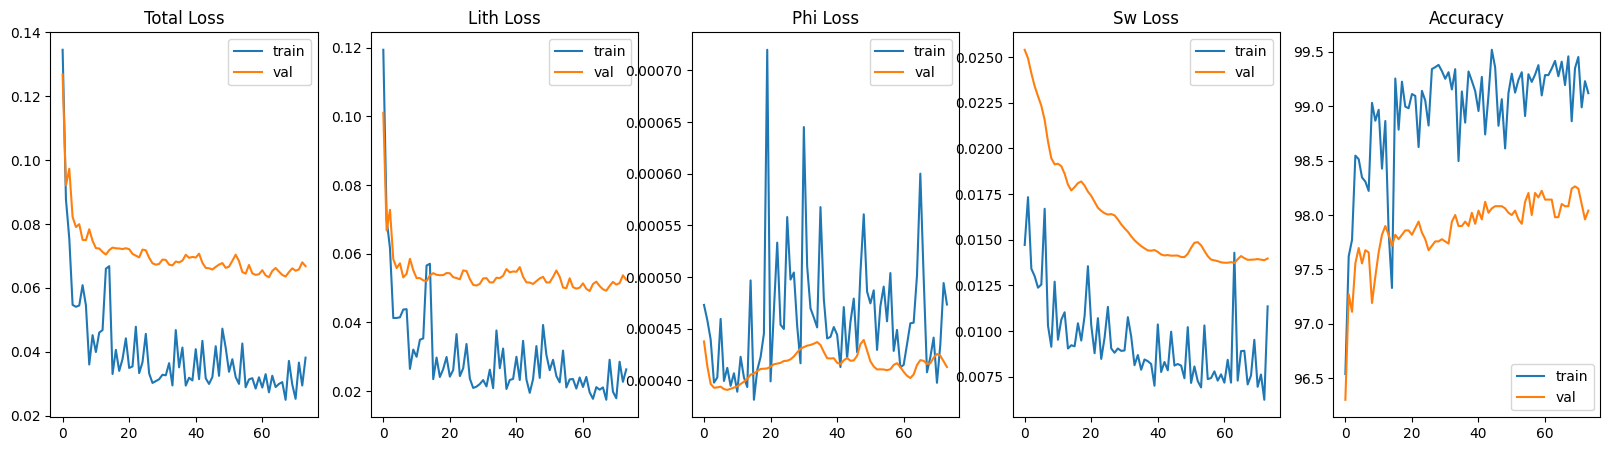

In [23]:
plot_all_losses_and_accuracies_curve(train_losses,
                                        val_losses, 
                                        train_lith_losses, 
                                        val_lith_losses, 
                                        train_phi_losses, 
                                        val_phi_losses,
                                        train_sw_losses, 
                                        val_sw_losses,
                                        train_accuracies, 
                                        val_accuracies,
                                        '')

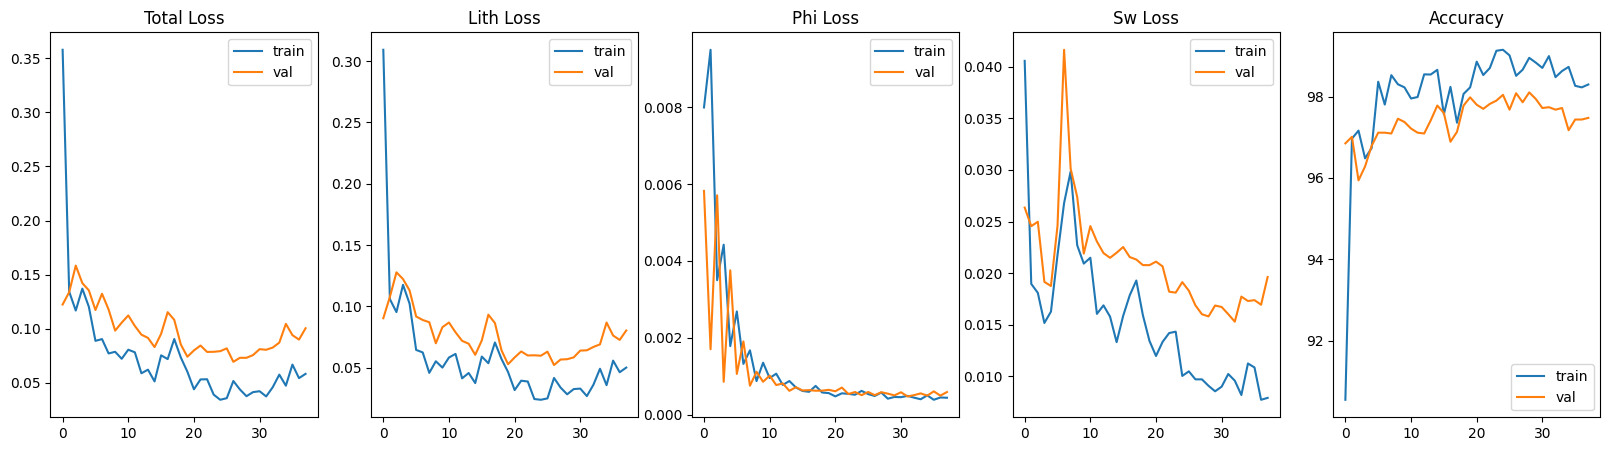

In [18]:
plot_all_losses_and_accuracies_curve(train_losses,
                                        val_losses, 
                                        train_lith_losses, 
                                        val_lith_losses, 
                                        train_phi_losses, 
                                        val_phi_losses,
                                        train_sw_losses, 
                                        val_sw_losses,
                                        train_accuracies, 
                                        val_accuracies,
                                        '')

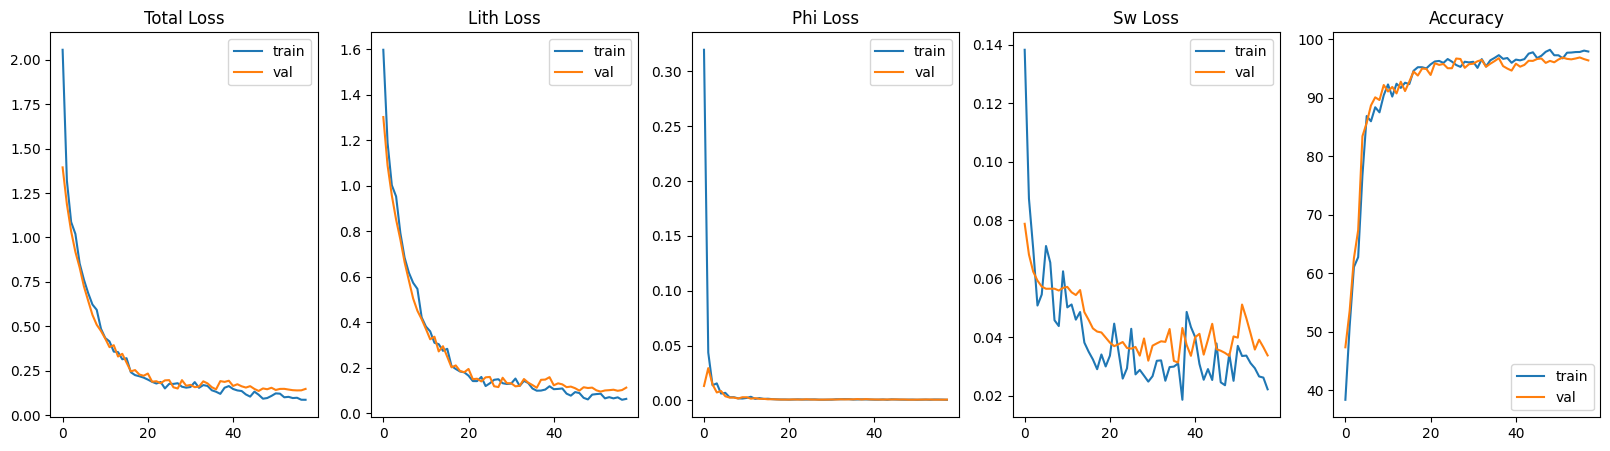

In [23]:
plot_all_losses_and_accuracies_curve(train_losses,
                                        val_losses, 
                                        train_lith_losses, 
                                        val_lith_losses, 
                                        train_phi_losses, 
                                        val_phi_losses,
                                        train_sw_losses, 
                                        val_sw_losses,
                                        train_accuracies, 
                                        val_accuracies,
                                        '')